<a href="https://colab.research.google.com/github/Savcdilara/MicrosoftStaj/blob/main/AESkeyGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================
# 🔐 AES Key Generation and Entropy Evaluation
# ====================================================
# Author: Dilara Savcı
# Project: AI-Based Dynamic Key Generation System
# Dataset: CIC-IDS2017
# Method: AES Key Generation (Baseline)
# ====================================================
!pip install pycryptodome
import pandas as pd
import numpy as np
import secrets
import time
import matplotlib.pyplot as plt
from google.colab import drive
import glob
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.4 MB/s eta 0:00:00


In [ ]:
# ====================================================
# 1️⃣ Load Dataset
# ====================================================
drive.mount('/content/drive')

path = "/content/drive/MyDrive/MachineLearningCVE/"
files = glob.glob(path + "*.csv")

df_list = []
for file in files:
    temp = pd.read_csv(file, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Mounted at /content/drive
✅ Dataset loaded successfully
Shape: (2830743, 79)
Columns: 79


In [ ]:
# ====================================================
# 2️⃣ Utility: Entropy and Key Generation
# ====================================================
def calculate_entropy(data):
    """Byte histogram üzerinden entropi hesaplar (maks: 8 bit/byte)"""
    if isinstance(data, str):
        data = data.encode()
    byte_counts = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256)
    probs = byte_counts / len(data)
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log2(probs))
    return entropy  # normalize etme

def generate_aes_key(key_size=256):
    """Belirtilen uzunlukta rastgele AES anahtarı üretir"""
    return get_random_bytes(key_size // 8)

In [ ]:
# ====================================================
# 3️⃣ Generate Multiple Keys and Combine for Stable Entropy
# ====================================================
num_keys = 1000
key_length = 256

all_bytes = b""
times = []

print("\n⏳ Generating AES keys...")

for _ in range(num_keys):
    start = time.time()
    key = generate_aes_key(key_length)
    end = time.time()

    all_bytes += key  # tüm anahtarları birleştir
    times.append(end - start)

# 🔹 Toplam entropiyi hesapla (daha güvenilir)
entropy = calculate_entropy(all_bytes)
mean_time = np.mean(times) * 1000  # ms cinsinden


⏳ Generating AES keys...


In [ ]:
# ====================================================
# 4️⃣ Statistical Analysis
# ====================================================
print("\n🔎 AES Key Generation Statistics")
print(f"Average Entropy: {np.mean(entropy):.4f} bits")
print(f"Min Entropy: {np.min(entropy):.4f}")
print(f"Max Entropy: {np.max(entropy):.4f}")
print(f"Average Generation Time: {np.mean(times)*1000:.4f} ms")


🔎 AES Key Generation Statistics
Average Entropy: 7.9947 bits
Min Entropy: 7.9947
Max Entropy: 7.9947
Average Generation Time: 0.0012 ms


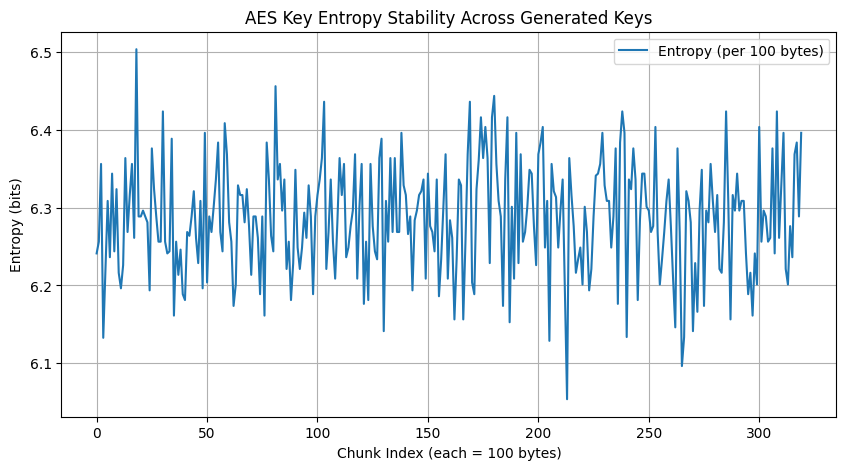

In [ ]:
# ====================================================
# 5️⃣ Visualization
# ====================================================
# Entropiyi parça bazında da görebilmek için 100’lük gruplar halinde ölçelim
chunk_size = 100
chunk_entropies = []

for i in range(0, len(all_bytes), chunk_size):
    chunk = all_bytes[i:i+chunk_size]
    if len(chunk) > 0:
        chunk_entropies.append(calculate_entropy(chunk))

plt.figure(figsize=(10,5))
plt.plot(chunk_entropies, label="Entropy (per 100 bytes)")
plt.title("AES Key Entropy Stability Across Generated Keys")
plt.xlabel("Chunk Index (each = 100 bytes)")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================================
# 6️⃣ Result Summary (for Academic Reporting)
# ====================================================
summary = {
    "Algorithm": "AES",
    "Key Length (bits)": key_length,
    "Number of Keys": num_keys,
    "Mean Entropy": round(entropy, 4),
    "Std Entropy": round(np.std(chunk_entropies), 4),
    "Mean Time (ms)": round(mean_time, 4)
}

results_df = pd.DataFrame([summary])
print("\n📊 Summary Table")
display(results_df)


📊 Summary Table


,Algorithm,Key Length (bits),Number of Keys,Mean Entropy,Std Entropy,Mean Time (ms)
0,AES,256,1000,7.9947,0.0717,0.0012


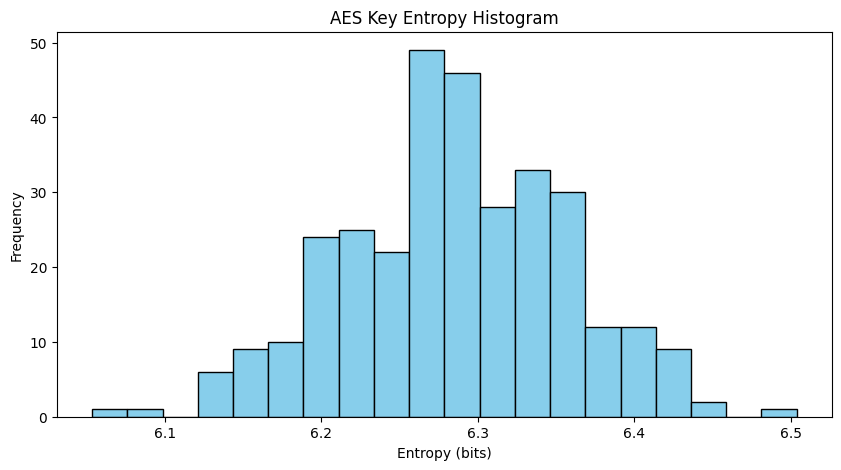

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(chunk_entropies, bins=20, color='skyblue', edgecolor='black')
plt.title("AES Key Entropy Histogram")
plt.xlabel("Entropy (bits)")
plt.ylabel("Frequency")
plt.show()